In [129]:
# SECTION 1 — IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

In [128]:
# SECTION 2 — LOAD DATA

df = pd.read_csv("loan_approval.csv")
df.head()



,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50.0,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55.0,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45.0,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50.0,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25.0,False


In [127]:
# SECTION 3 — CLEAN TARGET COLUMN

def clean_target(x):
    x = str(x).strip().lower()
    if "true" in x or "yes" in x: return 1
    if "false" in x or "no" in x: return 0
    return np.nan

df["loan_approved"] = df["loan_approved"].apply(clean_target)
df = df.dropna(subset=["loan_approved"])
df["loan_approved"].value_counts()



Series([], Name: count, dtype: int64)

In [126]:
# SECTION 4 — SELECT FEATURES (NUMERIC ONLY)

numeric_cols = ["income", "credit_score", "loan_amount", "years_employed", "points"]

X = df[numeric_cols].copy()
y = df["loan_approved"]

X = X.fillna(X.median())

summary statistics:


,income,credit_score,loan_amount,years_employed,points
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,90585.977000,573.946000,25308.503000,20.441000,56.680000
std,34487.874907,160.564945,14207.320147,11.777813,18.638033
min,30053.000000,300.000000,1022.000000,0.000000,10.000000
25%,61296.250000,433.000000,12748.750000,10.000000,45.000000
50%,90387.500000,576.000000,25661.500000,21.000000,55.000000
75%,120099.750000,715.000000,37380.500000,31.000000,70.000000
max,149964.000000,850.000000,49999.000000,40.000000,100.000000



missing values per column:
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
dtype: int64


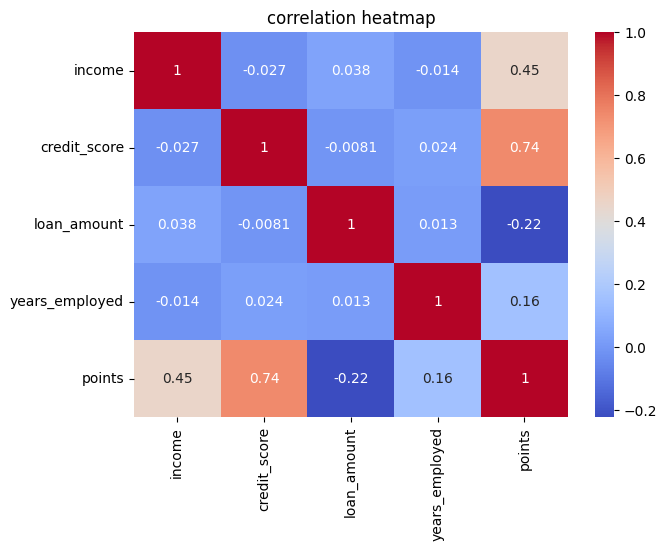

In [125]:
# SECTION 5 — EXPLORATORY DATA ANALYSIS (EDA)

# check basic info
print("summary statistics:")
display(X.describe())

print("\nmissing values per column:")
print(X.isna().sum())

# correlation heatmap
plt.figure(figsize=(7,5))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("correlation heatmap")
plt.show()



In [124]:
# SECTION 6 — SCALING AND TRAIN–TEST SPLIT
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)



In [123]:
# SECTION 7 — METRIC FUNCTION FOR SUPERVISED MODELS
def get_metrics(model, name):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print("accuracy :", accuracy_score(y_test, pred))
    print("precision:", precision_score(y_test, pred))
    print("recall   :", recall_score(y_test, pred))
    print("f1 score :", f1_score(y_test, pred))
    print("roc auc  :", roc_auc_score(y_test, proba))

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "Proba": proba
    }


In [122]:
# SECTION 8 — LOGISTIC REGRESSION
lr = LogisticRegression()
lr.fit(X_train, y_train)
m_lr = get_metrics(lr, "Logistic Regression")
proba_lr = m_lr["Proba"]




Logistic Regression
accuracy : 1.0
precision: 1.0
recall   : 1.0
f1 score : 1.0
roc auc  : 1.0


/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value enc

In [121]:

# SECTION 9 — DECISION TREE
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
m_dt = get_metrics(dt, "Decision Tree")
proba_dt = m_dt["Proba"]


Decision Tree
accuracy : 1.0
precision: 1.0
recall   : 1.0
f1 score : 1.0
roc auc  : 1.0


In [120]:
# SECTION 10 — RANDOM FOREST
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
m_rf = get_metrics(rf, "Random Forest")
proba_rf = m_rf["Proba"]



Random Forest
accuracy : 1.0
precision: 1.0
recall   : 1.0
f1 score : 1.0
roc auc  : 1.0


In [119]:
# SECTION 11 — KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
m_knn = get_metrics(knn, "KNN")
proba_knn = m_knn["Proba"]



KNN
accuracy : 0.9933333333333333
precision: 0.9887218045112782
recall   : 0.9962121212121212
f1 score : 0.9924528301886792
roc auc  : 0.9993574134199135


In [118]:
# SECTION 12 — NAIVE BAYES
nb = GaussianNB()
nb.fit(X_train, y_train)
m_nb = get_metrics(nb, "Naive Bayes")
proba_nb = m_nb["Proba"]



Naive Bayes
accuracy : 0.9616666666666667
precision: 0.9839357429718876
recall   : 0.928030303030303
f1 score : 0.9551656920077972
roc auc  : 0.9923566017316018


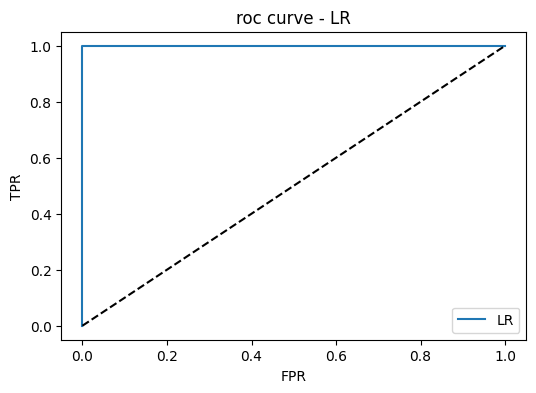

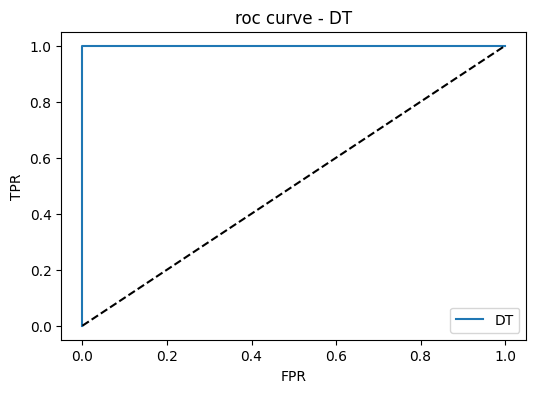

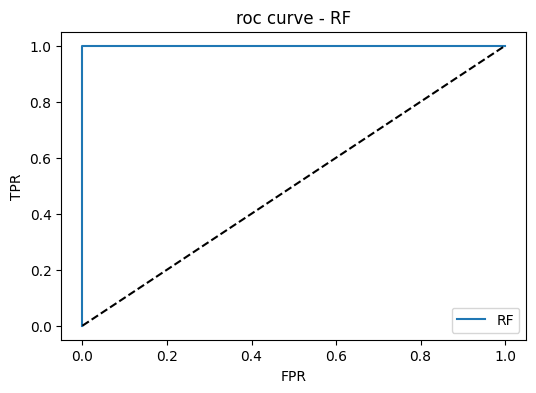

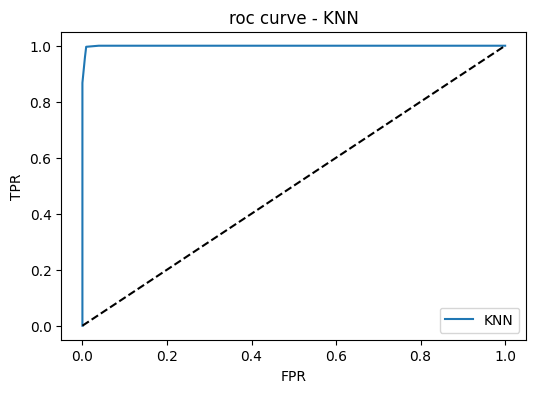

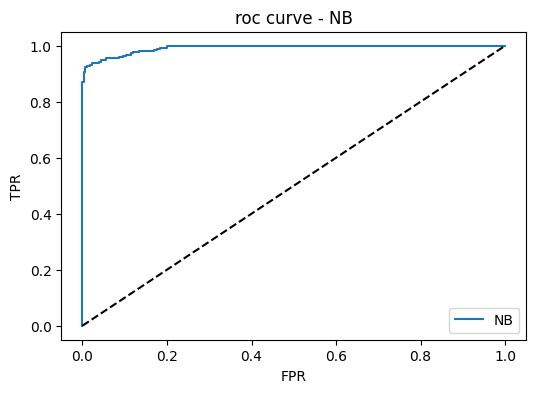

In [117]:
# SECTION 13 — INDIVIDUAL ROC CURVES
models_roc = [
    ("LR", proba_lr),
    ("DT", proba_dt),
    ("RF", proba_rf),
    ("KNN", proba_knn),
    ("NB", proba_nb)
]
for name, proba in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=name)
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"roc curve - {name}")
    plt.legend()
    plt.show()


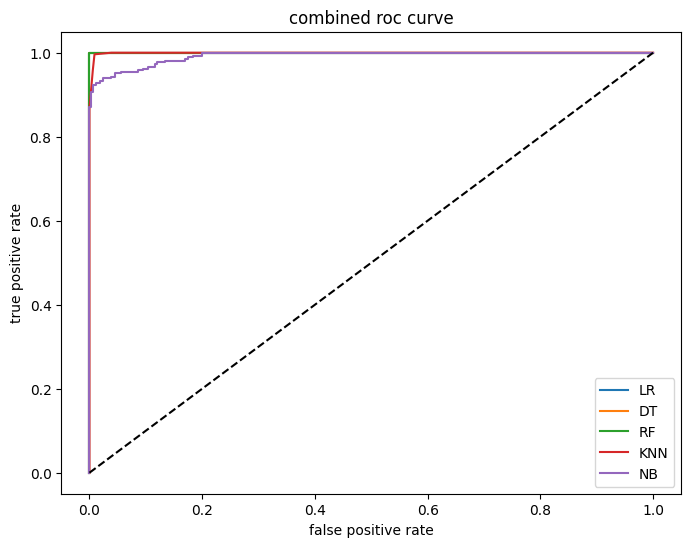

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
1,Decision Tree,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,KNN,0.993333,0.988722,0.996212,0.992453,0.999357
4,Naive Bayes,0.961667,0.983936,0.928030,0.955166,0.992357


In [116]:
# SECTION 14 — COMBINED ROC CURVE (ALL MODELS)
plt.figure(figsize=(8,6))

for name, proba in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],"k--")
plt.title("combined roc curve")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend()
plt.show()
supervised_results = pd.DataFrame([
    m_lr, m_dt, m_rf, m_knn, m_nb
])[["Model","Accuracy","Precision","Recall","F1 Score","ROC-AUC"]]

supervised_results


In [115]:
# k-means clustering setup

# ensuring scaled array for clustering
X_scaled = X_scaled if isinstance(X_scaled, np.ndarray) else X_scaled.values

# choosing number of clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# assigning clusters
df["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

print(df["kmeans_cluster"].value_counts())



kmeans_cluster
1    740
2    635
0    625
Name: count, dtype: int64


/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_s

In [ ]:
# SECTION 16 — K-MEANS CLUSTERING (INDIVIDUAL MODEL)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# run k-means with k=3
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df["kmeans_cluster"] = kmeans_labels

print("k-means cluster counts:")
print(df["kmeans_cluster"].value_counts())

k-means cluster counts:
kmeans_cluster
1    740
2    635
0    625
Name: count, dtype: int64


/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_s

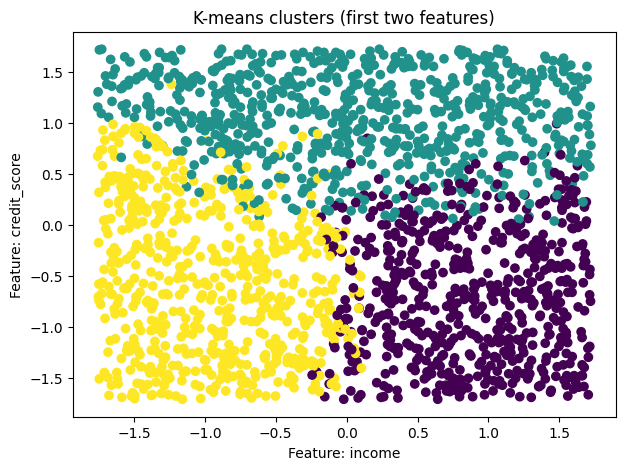

In [ ]:
# SECTION 17 — K-MEANS CLUSTER PLOT

plt.figure(figsize=(7,5))
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_labels,
    cmap="viridis"
)
plt.xlabel("Feature: " + numeric_cols[0])
plt.ylabel("Feature: " + numeric_cols[1])
plt.title("K-means clusters (first two features)")
plt.show()


In [114]:
# SECTION 18 — K-MEANS METRICS (SILHOUETTE + DAVIES-BOULDIN)

kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(X_scaled, kmeans_labels)

print("\nK-means Silhouette Score:", round(kmeans_sil, 3))
print("K-means Davies–Bouldin Index:", round(kmeans_db, 3))


K-means Silhouette Score: 0.22
K-means Davies–Bouldin Index: 1.578


/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

In [113]:
# SECTION 19 — K-MEANS CLUSTER FEATURE PROFILES

cluster_profiles = df.groupby("kmeans_cluster")[numeric_cols].mean()
print("\nK-means cluster feature profiles:")
print(cluster_profiles)





K-means cluster feature profiles:
                       income  credit_score   loan_amount  years_employed  \
kmeans_cluster                                                              
0               120726.136000    462.969600  26153.643200       19.406400   
1                93409.722973    742.990541  23286.139189       21.694595   
2                57629.801575    486.177953  26833.442520       19.998425   

                   points  
kmeans_cluster             
0               53.192000  
1               75.979730  
2               37.622047  


In [112]:
# SECTION 20 — HIERARCHICAL CLUSTERING (MODEL)

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# run hierarchical clustering (k = 3 to match k-means)
hc = AgglomerativeClustering(n_clusters=3, linkage="ward")
hc_labels = hc.fit_predict(X_scaled)

df["hier_cluster"] = hc_labels

print("\nHierarchical cluster counts:")
print(df["hier_cluster"].value_counts())




Hierarchical cluster counts:
hier_cluster
0    899
1    566
2    535
Name: count, dtype: int64


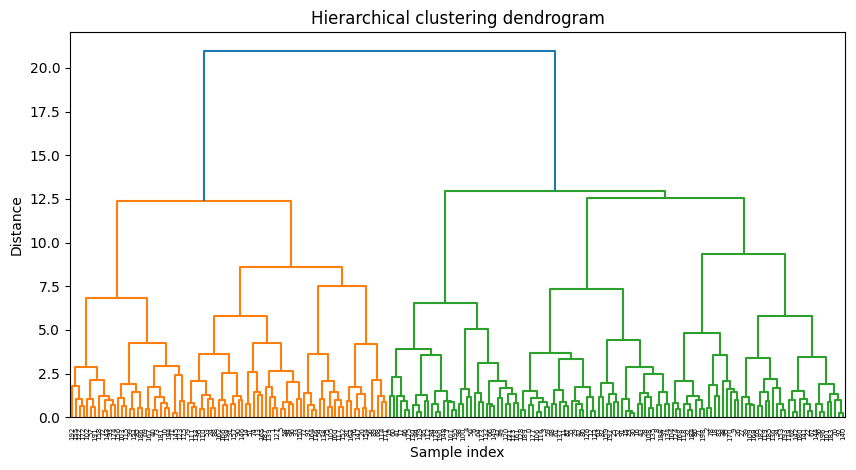

In [111]:
# SECTION 21 — HIERARCHICAL DENDROGRAM

# using a subset for clean dendrogram
subset = X_scaled[:200]

Z = linkage(subset, method="ward")

plt.figure(figsize=(10,5))
dendrogram(Z)
plt.title("Hierarchical clustering dendrogram")
plt.xlabel("Sample index")
plt.ylabel("Distance")
plt.show()


In [110]:
# SECTION 22 — HIERARCHICAL METRICS (SILHOUETTE + DB)

hc_sil = silhouette_score(X_scaled, hc_labels)
hc_db = davies_bouldin_score(X_scaled, hc_labels)

print("\nHierarchical Silhouette Score:", round(hc_sil, 3))
print("Hierarchical Davies–Bouldin Index:", round(hc_db, 3))




Hierarchical Silhouette Score: 0.189
Hierarchical Davies–Bouldin Index: 1.634


/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/sachi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: Run

In [109]:
# SECTION 23 — UNSUPERVISED MODEL COMPARISON TABLE

unsup_results = pd.DataFrame({
    "Model": ["K-Means", "Hierarchical"],
    "Silhouette Score": [kmeans_sil, hc_sil],
    "Davies-Bouldin Index": [kmeans_db, hc_db]
})

print("\nUnsupervised Comparison Table:")
print(unsup_results)


Unsupervised Comparison Table:
          Model  Silhouette Score  Davies-Bouldin Index
0       K-Means          0.219706              1.577578
1  Hierarchical          0.188827              1.634443
